In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
BATCH_SIZE = 128
EPOCHS = 30
LATENT_DIM = 2        # espace latent en 2D (pour visualisation t-SNE/PCA)
LR = 1e-3
INPUT_DIM = 784       # 28x28 pixels aplatis
HIDDEN_DIM = 400

# Chargement MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()   # Convertit en tenseur ET normalise [0,1]
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

Train: 60000 images | Test: 10000 images


# DIM VECT LATENT = 2

## VAE

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        
        # --- ENCODEUR : x -> (mu, logvar) ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)  # moyenne
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # log(variance)
        
        # --- DECODEUR : z -> x' ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()   # sortie entre [0,1] pour correspondre aux pixels normalisés
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        # Trick de reparamétrisation : z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)   # sigma = exp(0.5 * logvar)
        eps = torch.randn_like(std)     # epsilon ~ N(0,1)
        return mu + std * eps
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
print(model)
print(f"Device utilisé : {device}")

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Device utilisé : cuda


## Fonction de perte (BCE + KL)

In [6]:
def loss_function(x_recon, x, mu, logvar):
    
    reconstruction_loss = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    KL_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return reconstruction_loss + KL_loss

- La BCE pénalise les pixels mal reconstruits.
- -La KL divergence force l'espace latent à rester proche d'une gaussienne standard N(0,1), ce qui rend la génération possible.

## Entraînement + courbe de loss

Epoch [01/30] | Loss: 189.75
Epoch [02/30] | Loss: 167.08
Epoch [03/30] | Loss: 163.40
Epoch [04/30] | Loss: 160.96
Epoch [05/30] | Loss: 159.24
Epoch [06/30] | Loss: 157.86
Epoch [07/30] | Loss: 156.79
Epoch [08/30] | Loss: 155.87
Epoch [09/30] | Loss: 155.09
Epoch [10/30] | Loss: 154.43
Epoch [11/30] | Loss: 153.80
Epoch [12/30] | Loss: 153.27
Epoch [13/30] | Loss: 152.78
Epoch [14/30] | Loss: 152.34
Epoch [15/30] | Loss: 151.97
Epoch [16/30] | Loss: 151.60
Epoch [17/30] | Loss: 151.26
Epoch [18/30] | Loss: 150.89
Epoch [19/30] | Loss: 150.62
Epoch [20/30] | Loss: 150.33
Epoch [21/30] | Loss: 150.10
Epoch [22/30] | Loss: 149.84
Epoch [23/30] | Loss: 149.55
Epoch [24/30] | Loss: 149.36
Epoch [25/30] | Loss: 149.13
Epoch [26/30] | Loss: 148.89
Epoch [27/30] | Loss: 148.74
Epoch [28/30] | Loss: 148.51
Epoch [29/30] | Loss: 148.31
Epoch [30/30] | Loss: 148.13


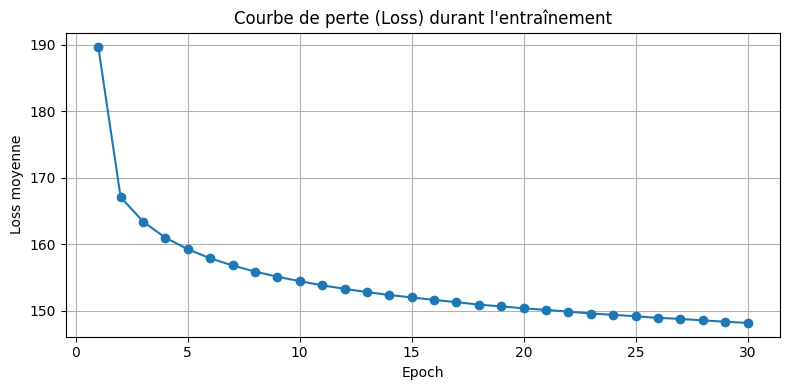

In [6]:
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for data, _ in train_loader:
        optimizer.zero_grad()
        
        # Aplatir les images : (batch, 1, 28, 28) -> (batch, 784)
        x = data.view(-1, INPUT_DIM).to(device)
        
        # Forward pass
        x_recon, mu, logvar = model(x)
        
        # Calcul de la perte
        loss = loss_function(x_recon, x, mu, logvar)
        
        # Backward + mise à jour
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {avg_loss:.2f}")
    

# Courbe de perte
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title("Courbe de perte (Loss) durant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss moyenne")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch [01/30] | Train Loss: 189.62 | Test Loss: 169.59
Epoch [02/30] | Train Loss: 167.18 | Test Loss: 164.07
Epoch [03/30] | Train Loss: 163.43 | Test Loss: 161.77
Epoch [04/30] | Train Loss: 161.27 | Test Loss: 159.98
Epoch [05/30] | Train Loss: 159.54 | Test Loss: 158.57
Epoch [06/30] | Train Loss: 158.14 | Test Loss: 157.23
Epoch [07/30] | Train Loss: 157.01 | Test Loss: 156.60
Epoch [08/30] | Train Loss: 155.98 | Test Loss: 155.62
Epoch [09/30] | Train Loss: 155.18 | Test Loss: 155.21
Epoch [10/30] | Train Loss: 154.48 | Test Loss: 154.51
Epoch [11/30] | Train Loss: 153.89 | Test Loss: 153.87
Epoch [12/30] | Train Loss: 153.27 | Test Loss: 153.59
Epoch [13/30] | Train Loss: 152.79 | Test Loss: 153.40
Epoch [14/30] | Train Loss: 152.29 | Test Loss: 153.05
Epoch [15/30] | Train Loss: 151.90 | Test Loss: 152.52
Epoch [16/30] | Train Loss: 151.52 | Test Loss: 152.37
Epoch [17/30] | Train Loss: 151.11 | Test Loss: 152.08
Epoch [18/30] | Train Loss: 150.77 | Test Loss: 152.27
Epoch [19/

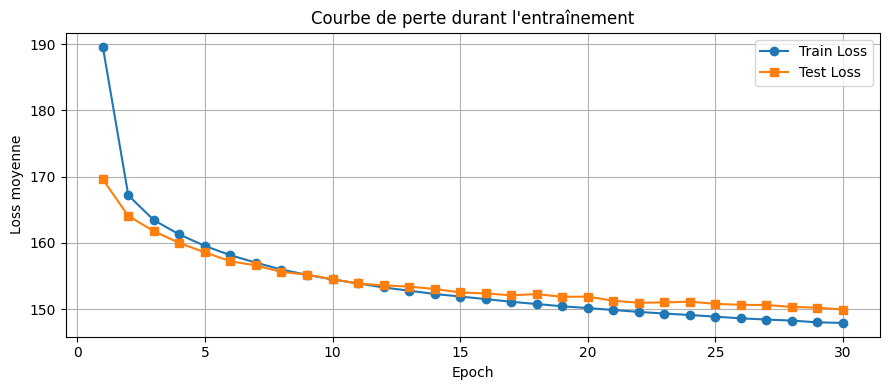

In [6]:
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
test_losses  = []

for epoch in range(EPOCHS):
    # --- Entraînement ---
    model.train()
    total_train_loss = 0

    for data, _ in train_loader:
        optimizer.zero_grad()
        x = data.view(-1, INPUT_DIM).to(device)
        x_recon, mu, logvar = model(x)
        loss = loss_function(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # --- Évaluation sur le test set ---
    model.eval()
    total_test_loss = 0

    with torch.no_grad():
        for data, _ in test_loader:
            x = data.view(-1, INPUT_DIM).to(device)
            x_recon, mu, logvar = model(x)
            total_test_loss += loss_function(x_recon, x, mu, logvar).item()

    avg_test_loss = total_test_loss / len(test_dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.2f} | Test Loss: {avg_test_loss:.2f}")

# --- Courbe de loss ---
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS+1), test_losses,  marker='s', label='Test Loss')
plt.title("Courbe de perte durant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss moyenne")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparaison originales / reconstruites

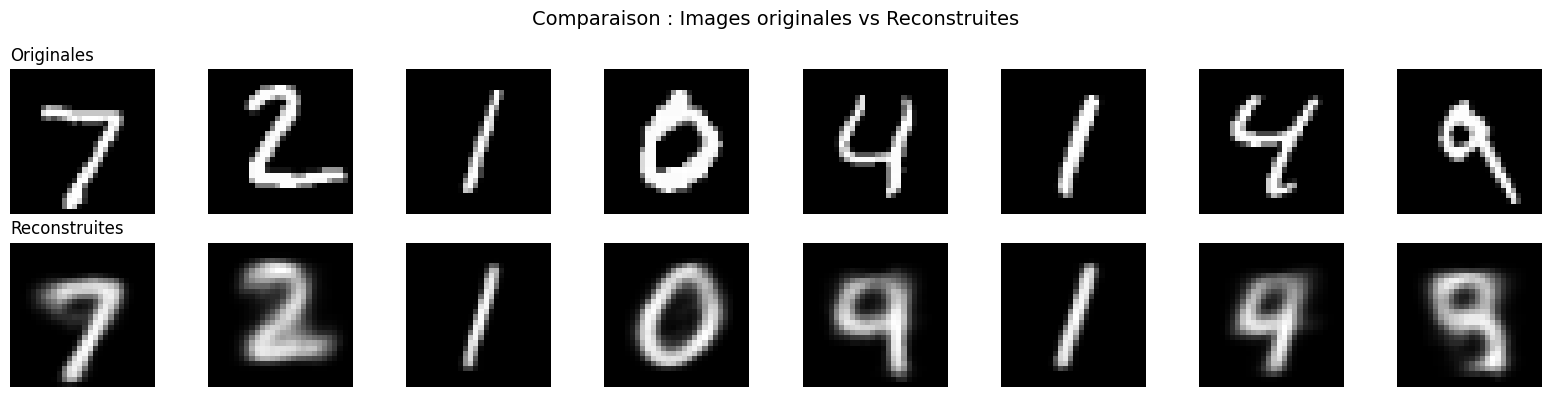

In [7]:
model.eval()

# Prendre un batch du test set
data_iter = iter(test_loader)
data, _ = next(data_iter)
x = data.view(-1, INPUT_DIM).to(device)

with torch.no_grad():
    x_recon, mu, logvar = model(x)

# Afficher 8 originales et 8 reconstruites
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))

for i in range(n):
    # Images originales (ligne du haut)
    axes[0, i].imshow(data[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Originales", fontsize=12, loc='left')
    
    # Images reconstruites (ligne du bas)
    axes[1, i].imshow(x_recon[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstruites", fontsize=12, loc='left')

plt.suptitle("Comparaison : Images originales vs Reconstruites", fontsize=14)
plt.tight_layout()
plt.show()

## Génération de 16 images

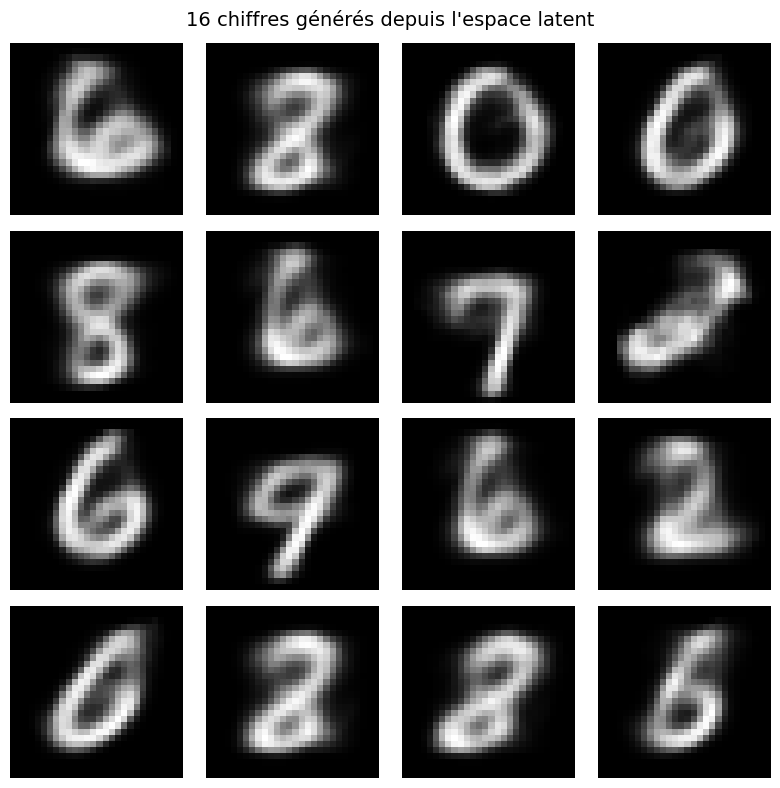

In [8]:
model.eval()

with torch.no_grad():
    # Échantillonner 16 vecteurs aléatoires dans l'espace latent
    z = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decode(z)

# Afficher les 16 images générées
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].view(28, 28).cpu().numpy(), cmap='gray')
    ax.axis('off')

plt.suptitle("16 chiffres générés depuis l'espace latent", fontsize=14)
plt.tight_layout()
plt.show()

## Visualisation espace latent 2D

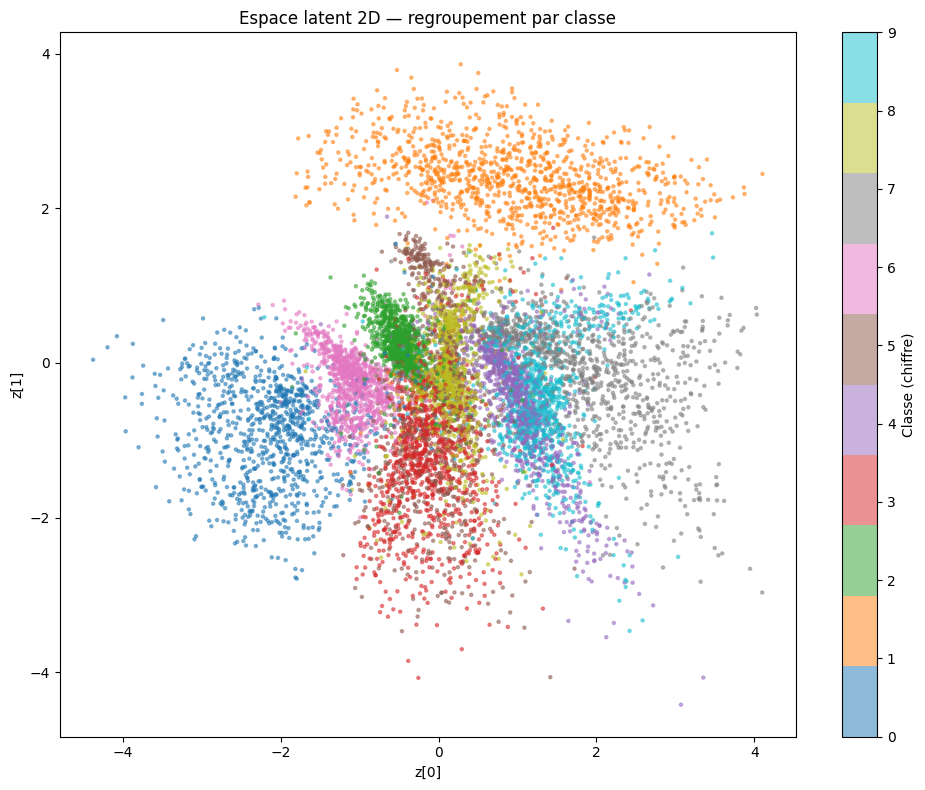

In [9]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        x = data.view(-1, INPUT_DIM).to(device)
        mu, logvar = model.encode(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# --- Visualisation directe en 2D (LATENT_DIM=2, pas besoin de PCA/t-SNE) ---
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                      c=all_labels, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, label='Classe (chiffre)')
plt.title("Espace latent 2D — regroupement par classe")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.tight_layout()
plt.show()

## Interpolation entre 2 points

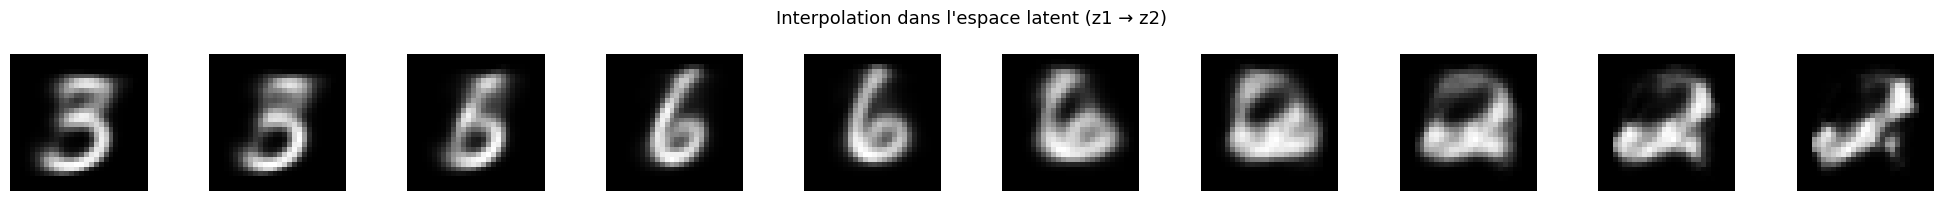

In [10]:
model.eval()

with torch.no_grad():
    # Deux points aléatoires dans l'espace latent
    z1 = torch.randn(1, LATENT_DIM).to(device)
    z2 = torch.randn(1, LATENT_DIM).to(device)
    
    # Interpoler en 10 étapes
    steps = 10
    images = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        img = model.decode(z_interp)
        images.append(img.view(28, 28).cpu().numpy())

# Afficher la transition
fig, axes = plt.subplots(1, steps, figsize=(20, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')

plt.suptitle("Interpolation dans l'espace latent (z1 → z2)", fontsize=13)
plt.tight_layout()
plt.show()

_________________

# DIM VECT LATENT = 20

In [7]:
BATCH_SIZE = 128
EPOCHS = 30
LATENT_DIM = 20 
LR = 1e-3
INPUT_DIM = 784
HIDDEN_DIM = 400

## VAE

In [8]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        
        # --- ENCODEUR plus profond pour mieux exploiter LATENT_DIM=20 ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu     = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        # --- DECODEUR plus profond ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
print(model)
print(f"Device utilisé : {device}")

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=200, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=200, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=200, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Device utilisé : cuda


Epoch [01/30] | Train Loss: 179.79 | Test Loss: 140.50
Epoch [02/30] | Train Loss: 130.77 | Test Loss: 122.51
Epoch [03/30] | Train Loss: 119.66 | Test Loss: 115.75
Epoch [04/30] | Train Loss: 114.78 | Test Loss: 112.11
Epoch [05/30] | Train Loss: 111.64 | Test Loss: 110.04
Epoch [06/30] | Train Loss: 109.49 | Test Loss: 107.85
Epoch [07/30] | Train Loss: 108.02 | Test Loss: 107.17
Epoch [08/30] | Train Loss: 106.85 | Test Loss: 106.40
Epoch [09/30] | Train Loss: 105.92 | Test Loss: 105.30
Epoch [10/30] | Train Loss: 105.16 | Test Loss: 104.85
Epoch [11/30] | Train Loss: 104.56 | Test Loss: 104.26
Epoch [12/30] | Train Loss: 103.98 | Test Loss: 104.24
Epoch [13/30] | Train Loss: 103.50 | Test Loss: 103.42
Epoch [14/30] | Train Loss: 103.05 | Test Loss: 103.17
Epoch [15/30] | Train Loss: 102.74 | Test Loss: 102.97
Epoch [16/30] | Train Loss: 102.37 | Test Loss: 102.40
Epoch [17/30] | Train Loss: 102.05 | Test Loss: 102.40
Epoch [18/30] | Train Loss: 101.84 | Test Loss: 102.20
Epoch [19/

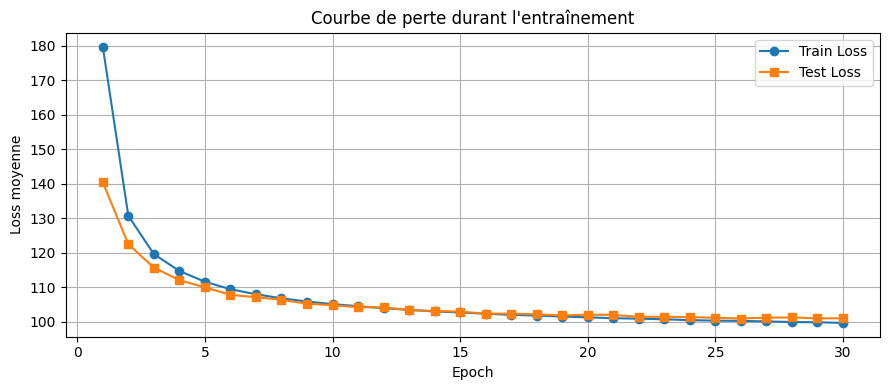

In [9]:
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
test_losses  = []

for epoch in range(EPOCHS):
    # --- Entraînement ---
    model.train()
    total_train_loss = 0

    for data, _ in train_loader:
        optimizer.zero_grad()
        x = data.view(-1, INPUT_DIM).to(device)
        x_recon, mu, logvar = model(x)
        loss = loss_function(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # --- Évaluation sur le test set ---
    model.eval()
    total_test_loss = 0

    with torch.no_grad():
        for data, _ in test_loader:
            x = data.view(-1, INPUT_DIM).to(device)
            x_recon, mu, logvar = model(x)
            total_test_loss += loss_function(x_recon, x, mu, logvar).item()

    avg_test_loss = total_test_loss / len(test_dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.2f} | Test Loss: {avg_test_loss:.2f}")

# --- Courbe de loss ---
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS+1), test_losses,  marker='s', label='Test Loss')
plt.title("Courbe de perte durant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss moyenne")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparaison originales / reconstruites

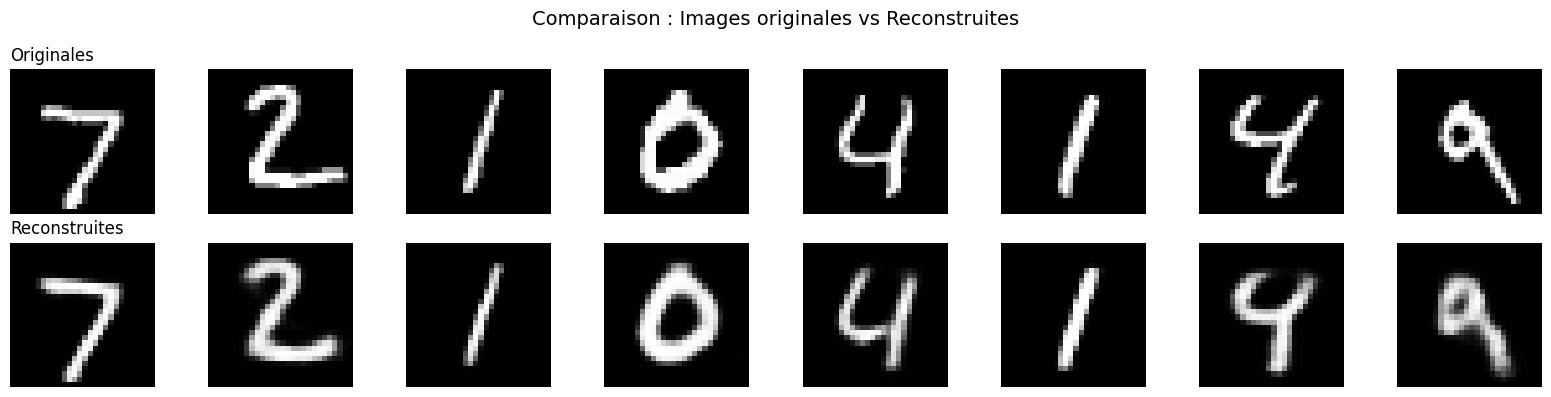

In [10]:
model.eval()

# Prendre un batch du test set
data_iter = iter(test_loader)
data, _ = next(data_iter)
x = data.view(-1, INPUT_DIM).to(device)

with torch.no_grad():
    x_recon, mu, logvar = model(x)

# Afficher 8 originales et 8 reconstruites
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))

for i in range(n):
    # Images originales (ligne du haut)
    axes[0, i].imshow(data[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Originales", fontsize=12, loc='left')
    
    # Images reconstruites (ligne du bas)
    axes[1, i].imshow(x_recon[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstruites", fontsize=12, loc='left')

plt.suptitle("Comparaison : Images originales vs Reconstruites", fontsize=14)
plt.tight_layout()
plt.show()

## Génération de 16 images

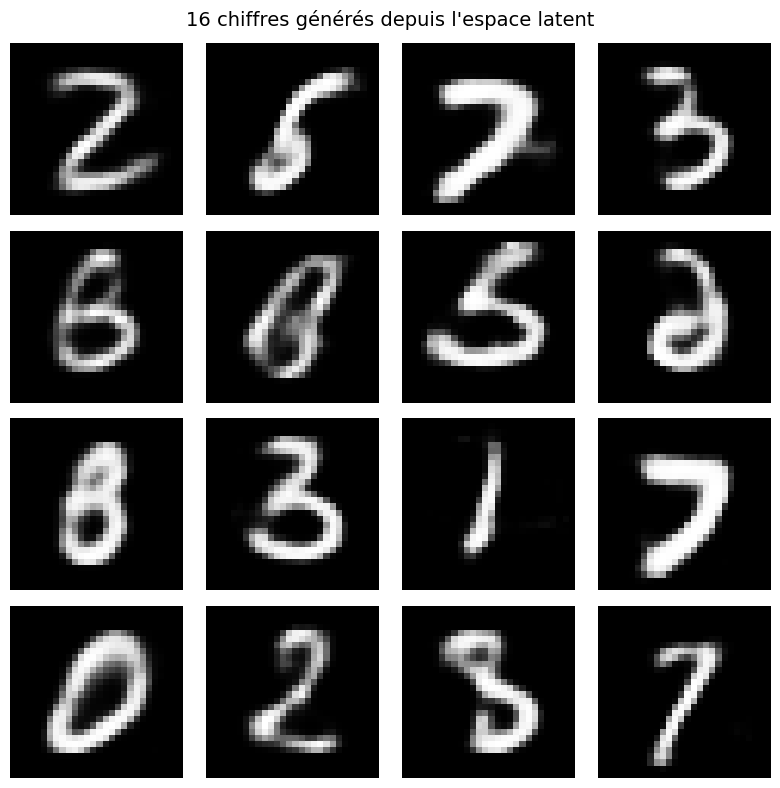

In [11]:
model.eval()

with torch.no_grad():
    # Échantillonner 16 vecteurs aléatoires dans l'espace latent
    z = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decode(z)

# Afficher les 16 images générées
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].view(28, 28).cpu().numpy(), cmap='gray')
    ax.axis('off')

plt.suptitle("16 chiffres générés depuis l'espace latent", fontsize=14)
plt.tight_layout()
plt.show()

## Visualisation espace latent avec t-SNE

Calcul t-SNE en cours (peut prendre ~1 minute)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


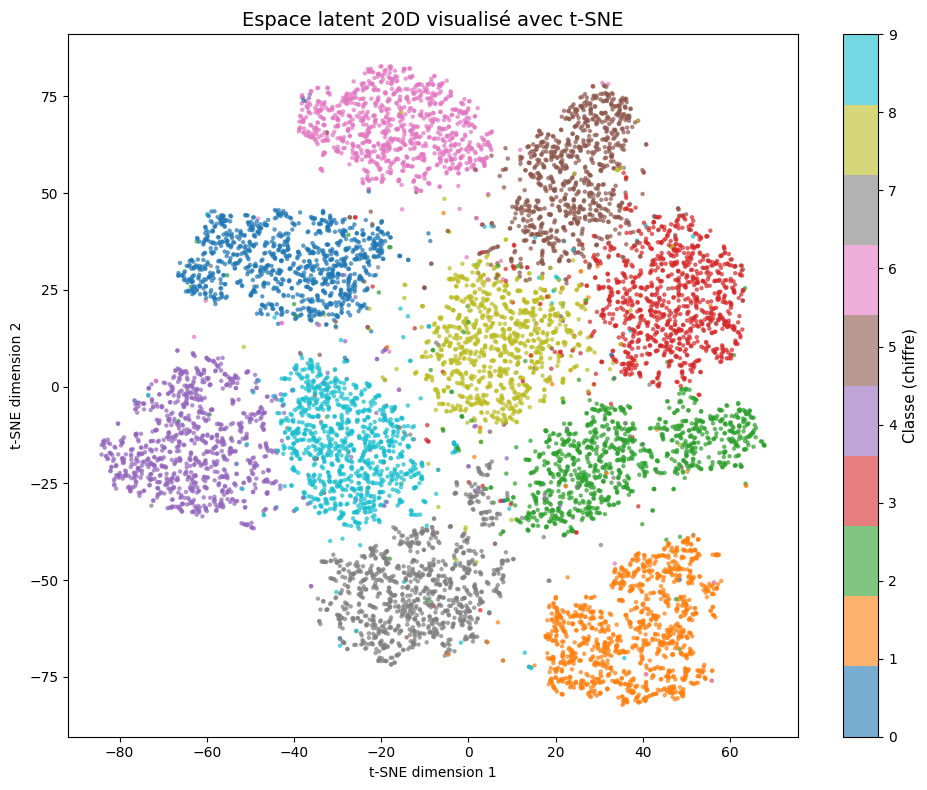

In [13]:
from sklearn.manifold import TSNE

model.eval()

all_mu     = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        x = data.view(-1, INPUT_DIM).to(device)
        mu, logvar = model.encode(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# t-SNE : réduction 20D -> 2D
print("Calcul t-SNE en cours (peut prendre ~1 minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
mu_2d = tsne.fit_transform(all_mu)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1],
                      c=all_labels, cmap='tab10', alpha=0.6, s=5)
cbar = plt.colorbar(scatter)
cbar.set_label('Classe (chiffre)', fontsize=11)
cbar.set_ticks(range(10))
cbar.set_ticklabels([str(i) for i in range(10)])   # ← CORRIGÉ

plt.title("Espace latent 20D visualisé avec t-SNE", fontsize=14)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

## Interpolation 

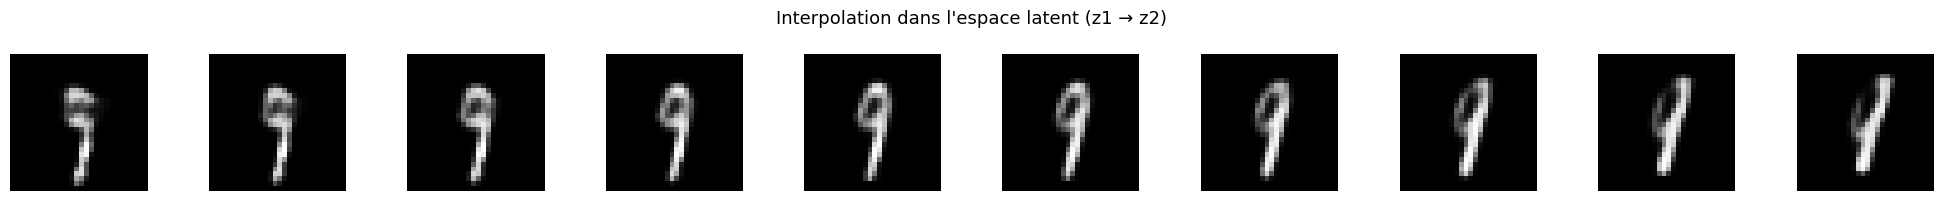

In [14]:
model.eval()

with torch.no_grad():
    z1 = torch.randn(1, LATENT_DIM).to(device)
    z2 = torch.randn(1, LATENT_DIM).to(device)
    
    steps = 10
    images = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        img = model.decode(z_interp)
        images.append(img.view(28, 28).cpu().numpy())

fig, axes = plt.subplots(1, steps, figsize=(20, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')

plt.suptitle("Interpolation dans l'espace latent (z1 → z2)", fontsize=13)
plt.tight_layout()
plt.show()